Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [ ]:
df = pd.read_csv('/content/Employee_Salary_Dataset.csv')

print("Dataset Preview")
display(df.head())

Dataset Preview


,ID,Experience_Years,Age,Gender,Salary
0,1,5,28,Female,250000
1,2,1,21,Male,50000
2,3,3,23,Female,170000
3,4,2,22,Male,25000
4,5,1,17,Male,10000


Dataset Overview

In [ ]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Shape:
(35, 5)

Columns:
Index(['ID', 'Experience_Years', 'Age', 'Gender', 'Salary'], dtype='object')

Data Types:
ID                   int64
Experience_Years     int64
Age                  int64
Gender              object
Salary               int64
dtype: object

Missing Values:
ID                  0
Experience_Years    0
Age                 0
Gender              0
Salary              0
dtype: int64

Duplicate Records:
0


Data Cleaning

In [ ]:
df = df.drop_duplicates()

print("Duplicates Removed Successfully")
print(df.shape)

Duplicates Removed Successfully
(35, 5)


Rename Columns

In [ ]:
df.columns = df.columns.str.lower()

print(df.columns)

Index(['id', 'experience_years', 'age', 'gender', 'salary'], dtype='object')


Save Cleaned Dataset

In [ ]:
df.to_csv(
    "employee_salary_cleaned.csv",
    index=False
)

print("Cleaned Dataset Saved")

Cleaned Dataset Saved


SQLite Database

In [ ]:
conn = sqlite3.connect(
    "employee_salary.db"
)

df.to_sql(
    "employees",
    conn,
    if_exists="replace",
    index=False
)

print("Database Created Successfully")

Database Created Successfully


Verify Records

In [ ]:
query = """
SELECT COUNT(*) AS Total_Records
FROM employees
"""

display(
    pd.read_sql(query, conn)
)

,Total_Records
0,35


SQL Query 1 - Filtering

In [ ]:
query = """
SELECT *
FROM employees
WHERE salary > 100000
"""

display(pd.read_sql(query, conn))

,id,experience_years,age,gender,salary
0,1,5,28,Female,250000
1,3,3,23,Female,170000
2,6,25,62,Male,5001000
3,7,19,54,Female,800000
4,10,15,54,Female,650000
5,11,4,26,Female,250000
6,12,6,29,Male,1400000
7,13,14,39,Male,6000050
8,14,11,40,Male,220100
9,17,10,34,Female,930000


SQL Query 2 - Sorting

In [ ]:
query = """
SELECT *
FROM employees
ORDER BY salary DESC
"""

display(pd.read_sql(query, conn))

,id,experience_years,age,gender,salary
0,28,27,62,Female,10000000
1,34,19,53,Female,9300000
2,18,15,54,Female,7900000
3,35,16,49,Male,7600000
4,23,5,29,Male,6845000
5,21,15,54,Male,6570000
6,13,14,39,Male,6000050
7,6,25,62,Male,5001000
8,29,19,54,Female,5000000
9,33,20,55,Female,1540000


SQL Query 3 - Aggregation

In [ ]:
query = """
SELECT AVG(salary) AS Average_Salary
FROM employees
"""

display(pd.read_sql(query, conn))

,Average_Salary
0,2.059147e+06


SQL Query 4 - Group By

In [ ]:
query = """
SELECT gender,
AVG(salary) AS Average_Salary
FROM employees
GROUP BY gender
"""

display(pd.read_sql(query, conn))

,gender,Average_Salary
0,Female,2.054917e+06
1,Male,2.063626e+06


SQL Query 5 - Conditional Query

In [ ]:
query = """
SELECT *
FROM employees
WHERE age > 25
AND salary > 100000
"""

display(pd.read_sql(query, conn))

,id,experience_years,age,gender,salary
0,1,5,28,Female,250000
1,6,25,62,Male,5001000
2,7,19,54,Female,800000
3,10,15,54,Female,650000
4,11,4,26,Female,250000
5,12,6,29,Male,1400000
6,13,14,39,Male,6000050
7,14,11,40,Male,220100
8,17,10,34,Female,930000
9,18,15,54,Female,7900000


SQL Transformation

In [ ]:
query = """
SELECT *,

CASE
    WHEN salary >= 200000
    THEN 'High Salary'

    WHEN salary >= 100000
    THEN 'Medium Salary'

    ELSE 'Low Salary'
END AS salary_category,

CASE
    WHEN experience_years >= 5
    THEN 'Experienced'

    ELSE 'Beginner'
END AS experience_level

FROM employees
"""

transformed_df = pd.read_sql(
    query,
    conn
)

display(transformed_df.head())

,id,experience_years,age,gender,salary,salary_category,experience_level
0,1,5,28,Female,250000,High Salary,Experienced
1,2,1,21,Male,50000,Low Salary,Beginner
2,3,3,23,Female,170000,Medium Salary,Beginner
3,4,2,22,Male,25000,Low Salary,Beginner
4,5,1,17,Male,10000,Low Salary,Beginner


Export Transformed Data

In [ ]:
transformed_df.to_csv(
    "employee_salary_transformed.csv",
    index=False
)

print("Transformed Dataset Saved")

Transformed Dataset Saved


ETL Pipeline

In [ ]:
def extract(path):
    return pd.read_csv(path)

def transform(data):
    data = data.drop_duplicates()
    return data

def load(data):
    data.to_csv(
        "etl_output.csv",
        index=False
    )

data = extract(
    "/content/Employee_Salary_Dataset.csv"
)

data = transform(data)

load(data)

print("ETL Pipeline Completed")

ETL Pipeline Completed


Install PySpark

In [ ]:
!pip install pyspark

Spark Session

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EmployeeSalaryProject") \
    .getOrCreate()

Bronze Layer

In [ ]:
bronze_df = spark.read.csv(
    "/content/Employee_Salary_Dataset.csv",
    header=True,
    inferSchema=True
)

bronze_df.write.mode(
    "overwrite"
).parquet(
    "/content/bronze_layer"
)

print("Bronze Layer Created")

Bronze Layer Created


Silver Layer

In [ ]:
silver_df = bronze_df.dropDuplicates()

silver_df.write.mode(
    "overwrite"
).parquet(
    "/content/silver_layer"
)

print("Silver Layer Created")

Silver Layer Created



Gold Layer

In [ ]:
from pyspark.sql.functions import avg,max,min,count

gold_df = silver_df.agg(
    avg("Salary").alias("Average_Salary"),
    max("Salary").alias("Highest_Salary"),
    min("Salary").alias("Lowest_Salary"),
    count("*").alias("Total_Employees")
)

gold_df.show()

+-----------------+--------------+-------------+---------------+
|   Average_Salary|Highest_Salary|Lowest_Salary|Total_Employees|
+-----------------+--------------+-------------+---------------+
|2059147.142857143|      10000000|         3000|             35|
+-----------------+--------------+-------------+---------------+



In [ ]:
gold_df.write.mode(
    "overwrite"
).parquet(
    "/content/gold_layer"
)

In [ ]:
import os


csv_size = os.path.getsize(
    "/content/Employee_Salary_Dataset.csv"
)

parquet_size = 0

for root, dirs, files in os.walk(
    "/content/gold_layer"
):
    for file in files:
        parquet_size += os.path.getsize(
            os.path.join(root, file)
        )

print("CSV Size:", csv_size, "bytes")
print("Parquet Size:", parquet_size, "bytes")

CSV Size: 809 bytes
Parquet Size: 827 bytes


In [ ]:
comparison_table = pd.DataFrame({
    "Feature":[
        "File Size",
        "Storage Efficiency",
        "Read Performance",
        "Write Performance",
        "Advantages",
        "Limitations"
    ],

    "CSV":[
        "Larger",
        "Lower",
        "Slower",
        "Faster",
        "Human Readable",
        "Consumes More Storage"
    ],

    "Parquet":[
        "Smaller",
        "Higher",
        "Faster",
        "Slightly Slower",
        "Columnar Storage",
        "Not Human Readable"
    ]
})

display(comparison_table)

,Feature,CSV,Parquet
0,File Size,Larger,Smaller
1,Storage Efficiency,Lower,Higher
2,Read Performance,Slower,Faster
3,Write Performance,Faster,Slightly Slower
4,Advantages,Human Readable,Columnar Storage
5,Limitations,Consumes More Storage,Not Human Readable


## CSV vs Parquet Comparison

Observation:

- Parquet generally occupies less storage space than CSV.
- Parquet provides faster analytical query performance due to columnar storage.
- CSV is easier to read and edit manually.
- Parquet is preferred for big data processing and analytics.

CSV vs Parquet

In [ ]:
import os

csv_size = os.path.getsize(
    "/content/Employee_Salary_Dataset.csv"
)

parquet_size = 0

for root, dirs, files in os.walk(
    "/content/gold_layer"
):
    for file in files:
        parquet_size += os.path.getsize(
            os.path.join(root, file)
        )

comparison = pd.DataFrame({
    "Format":["CSV","Parquet"],
    "Size(Bytes)":[csv_size, parquet_size]
})

display(comparison)

,Format,Size(Bytes)
0,CSV,809
1,Parquet,827


Parquet to Pandas

In [ ]:
parquet_df = spark.read.parquet(
    "/content/gold_layer"
)

pandas_df = parquet_df.toPandas()

display(pandas_df)

,Gender,Average_Salary
0,Female,2.054917e+06
1,Male,2.063626e+06


Visualization 1 - Gender Distribution

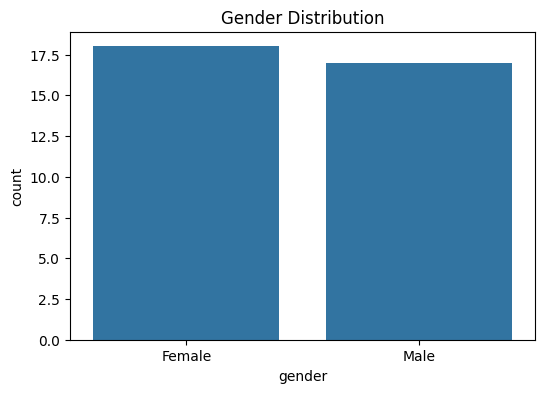

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='gender',
    data=df
)

plt.title("Gender Distribution")

plt.show()

Visualization 2 - Salary Distribution

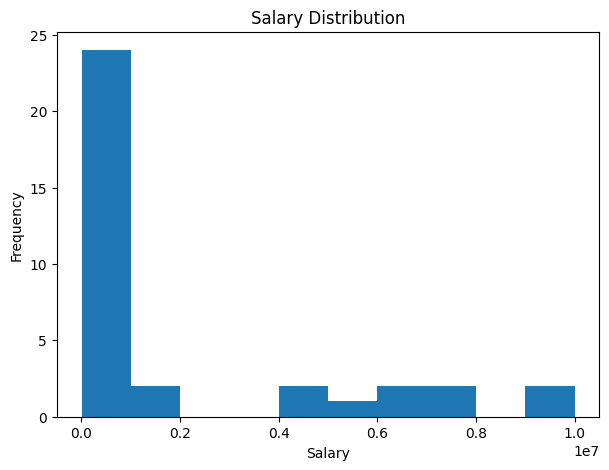

In [ ]:
plt.figure(figsize=(7,5))

plt.hist(
    df['salary'],
    bins=10
)

plt.title("Salary Distribution")

plt.xlabel("Salary")

plt.ylabel("Frequency")

plt.show()

Visualization 3 - Experience vs Salary

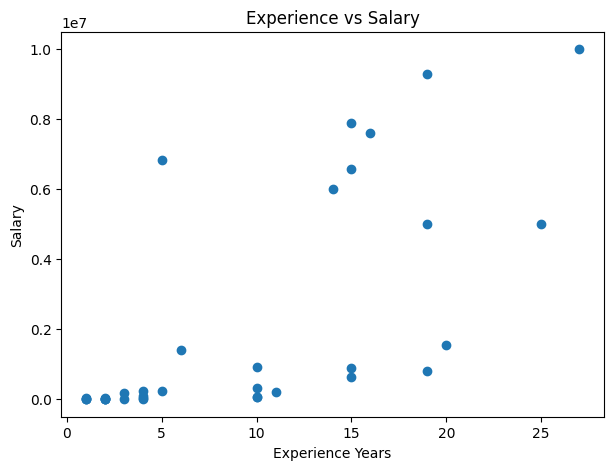

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    df['experience_years'],
    df['salary']
)

plt.xlabel("Experience Years")

plt.ylabel("Salary")

plt.title("Experience vs Salary")

plt.show()

Machine Learning Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
X = df[['experience_years','age']]

X = pd.get_dummies(
    pd.concat(
        [X, df[['gender']]],
        axis=1
    ),
    drop_first=True
)

y = df['salary']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

predictions = model.predict(
    X_test
)

In [ ]:
print(
    "MAE:",
    mean_absolute_error(
        y_test,
        predictions
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        predictions
    )
)

MAE: 1158453.2002919572
R2 Score: -185.89116595002594
